In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.io as sio
import tensorflow as tf


import models as models

In [2]:
sigma1 = 0.5
sigma2 = 0.8
sigma3 = 0.6
mu1 = 0
mu2 = 2
mu3 = -2

eps = 5
T = 1


def prior_fn(x):
    T1 = (x - mu1) ** 2 / sigma1 ** 2
    f1 = 1 / np.sqrt(2*np.pi*sigma1**2) * np.exp(-T1/2)
    T2 = (x - mu2) ** 2 / sigma2 ** 2
    f2 = 1 / np.sqrt(2*np.pi*sigma2**2) * np.exp(-T2/2)
    T3 = (x - mu3) ** 2 / sigma3 ** 2
    f3 = 1 / np.sqrt(2*np.pi*sigma3**2) * np.exp(-T3/2)
    return f1 / 3 + f2 / 3 + f3 / 3


# def posterior_fn(x, yt):
#     T1 = (x - mu1) ** 2 / sigma1 ** 2
#     f1 = 1 / np.sqrt(2*np.pi*sigma1**2) * np.exp(-T1/2)
#     T2 = (x - mu2) ** 2 / sigma2 ** 2
#     f2 = 1 / np.sqrt(2*np.pi*sigma2**2) * np.exp(-T2/2)
#     T3 = (x - mu3) ** 2 / sigma3 ** 2
#     f3 = 1 / np.sqrt(2*np.pi*sigma3**2) * np.exp(-T3/2)
#     A = f1 / 3 + f2 / 3 + f3 / 3
    
#     B = 1 / np.sqrt(2*np.pi*eps*T) * np.exp(-(x-yt) ** 2 / 2 / eps / T)
    
#     T1 = (yt - mu1) ** 2 / (sigma1 ** 2 + eps * T)
#     T2 = (yt - mu2) ** 2 / (sigma2 ** 2 + eps * T)
#     T3 = (yt - mu3) ** 2 / (sigma3 ** 2 + eps * T)
    
#     C1 = 1/C(T, sigma1) * np.exp(-T1/2)
#     C2 = 1/C(T, sigma2) * np.exp(-T2/2)
#     C3 = 1/C(T, sigma3) * np.exp(-T3/2)
    
#     return A * B / (C1/3 + C2/3 + C3/3)


def C(t, sigma):
    return np.sqrt(2 * np.pi * (sigma ** 2 + eps * t))


def posterior_fn(x, yt, t):
    T1 = (x - mu1) ** 2 / (sigma1 ** 2 + eps * t * 1)
    # f1 = 1 / np.sqrt(2*np.pi*sigma1**2) * np.exp(-T1/2)
    f1 = 1 / C(t, sigma1) * np.exp(-T1/2)
    T2 = (x - mu2) ** 2 / (sigma2 ** 2 + eps * t * 1)
    # f2 = 1 / np.sqrt(2*np.pi*sigma2**2) * np.exp(-T2/2)
    f2 = 1 / C(t, sigma2) * np.exp(-T2/2)
    T3 = (x - mu3) ** 2 / (sigma3 ** 2 + eps * t * 1)
    # f3 = 1 / np.sqrt(2*np.pi*sigma3**2) * np.exp(-T3/2)
    f3 = 1 / C(t, sigma3) * np.exp(-T3/2)
    A = f1 / 3 + f2 / 3 + f3 / 3
    
    B = 1 / np.sqrt(2*np.pi*eps*(T-t)) * np.exp(-(x-yt) ** 2 / 2 / eps / (T-t))
    
    T1 = (yt - mu1) ** 2 / (sigma1 ** 2 + eps * T)
    T2 = (yt - mu2) ** 2 / (sigma2 ** 2 + eps * T)
    T3 = (yt - mu3) ** 2 / (sigma3 ** 2 + eps * T)
    
    C1 = 1/C(T, sigma1) * np.exp(-T1/2)
    C2 = 1/C(T, sigma2) * np.exp(-T2/2)
    C3 = 1/C(T, sigma3) * np.exp(-T3/2)
    
    return A * B / (C1/3 + C2/3 + C3/3)

In [3]:
x = np.linspace(-5, 5, 1001)
model = models.NN(units=50, name="nn_1000000", eps=5, activation=tf.tanh)
model.restore()

forward_fn = tf.function(model.call)

In [4]:
dt = 0.0001

M = int(1e5)
yt = 2

_zts = [yt * np.ones([M, 1])]
t = 0.0
tt = tf.ones([M, 1])
for i in range(int(T/dt)):

    update = forward_fn(
        (T - t) * tt,
        tf.constant(_zts[-1].reshape([-1, 1]), tf.float32),            
    ).numpy()
    zt = _zts[-1] + eps * update * dt + \
        np.sqrt(eps) * np.random.normal(size=_zts[-1].shape) * np.sqrt(dt)
    _zts += [zt]
    t = t + dt
zts = np.stack(_zts, axis=0)

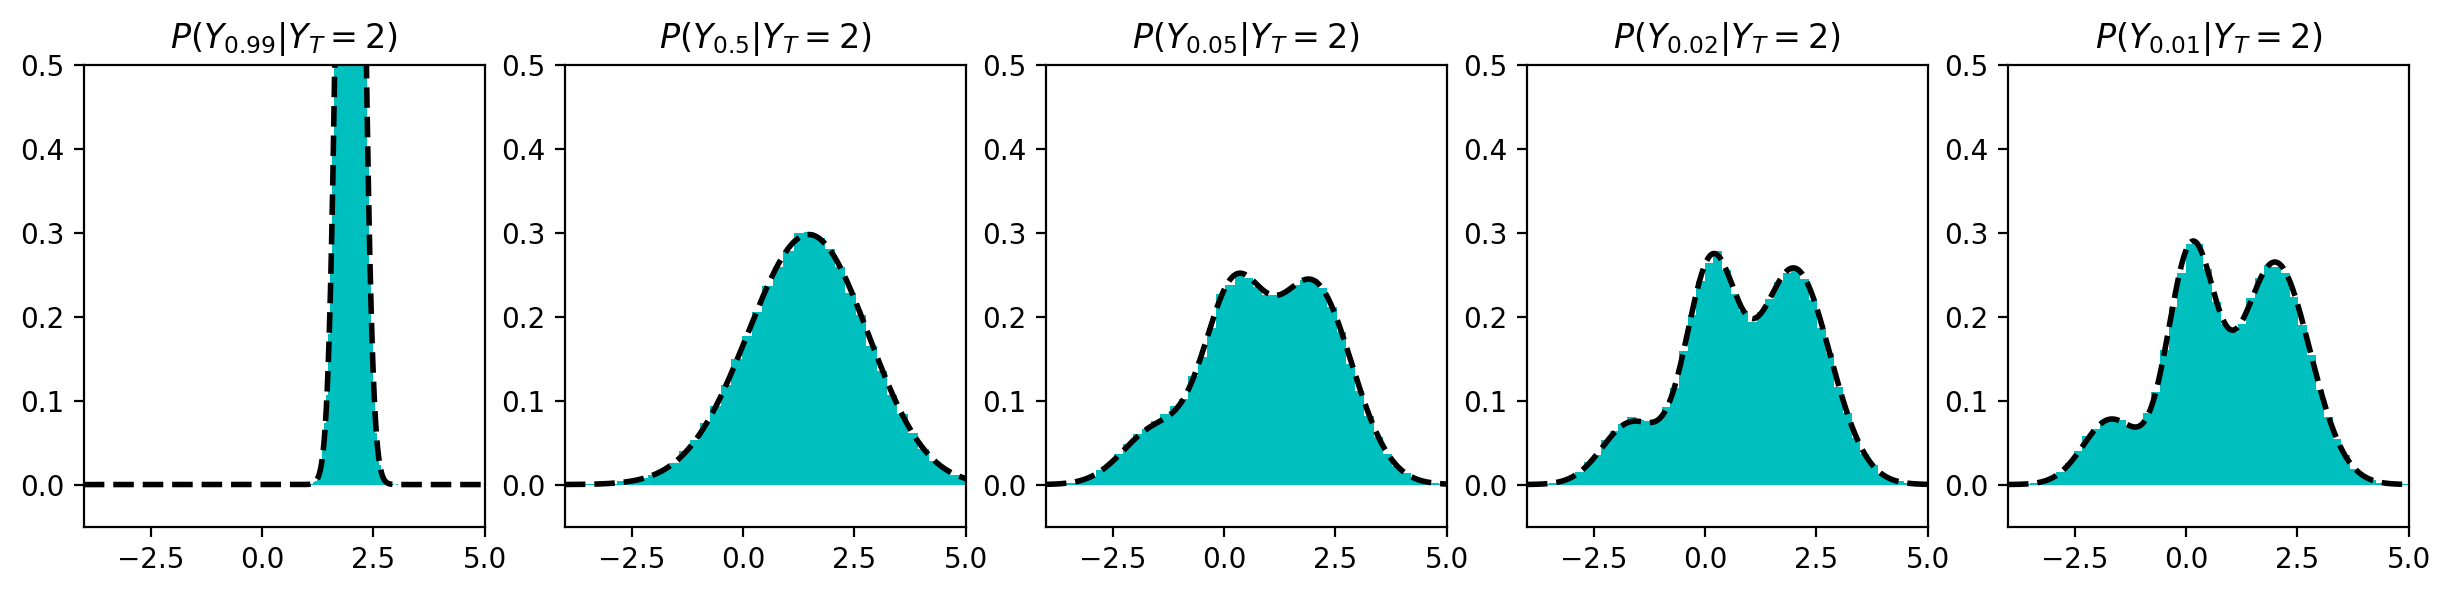

In [5]:
x = np.linspace(-4, 5, 10001)
fig, axes = plt.subplots(1, 5, figsize=[15, 3], dpi=200)



axes[0].hist(zts[100, :, 0], bins=50, density=True, color="c")
axes[0].plot(x, posterior_fn(x, yt, 0.99), "k--", linewidth=2)
axes[0].set_title("$P(Y_{0.99}|Y_T=2)$")


axes[1].hist(zts[5000, :, 0], bins=50, density=True, color="c")
axes[1].plot(x, posterior_fn(x, yt, 0.5), "k--", linewidth=2)
axes[1].set_title("$P(Y_{0.5}|Y_T=2)$")


axes[2].hist(zts[9500, :, 0], bins=50, density=True, color="c")
axes[2].plot(x, posterior_fn(x, yt, 0.05), "k--", linewidth=2)
axes[2].set_title("$P(Y_{0.05}|Y_T=2)$")


axes[3].hist(zts[9800, :, 0], bins=50, density=True, color="c")
axes[3].plot(x, posterior_fn(x, yt, 0.02), "k--", linewidth=2)
axes[3].set_title("$P(Y_{0.02}|Y_T=2)$")


axes[4].hist(zts[9900, :, 0], bins=50, density=True, color="c")
axes[4].plot(x, posterior_fn(x, yt, 0.01), "k--", linewidth=2)
# axes[4].hist(zts[1000, :, 0], bins=50, density=True, color="r", alpha=1) #histtype="step", linewidth=2, linestyle="--")
axes[4].set_title("$P(Y_{0.01}|Y_T=2)$")

# axes[i].set_title("$Y_T={}$".format(str(yts[i])))
# axes[i].set_title("$\\tau={}$".format(str(i*200*0.001)))
#     axes[i].set_ylim([-0.05, 0.5])
#     axes[i].set_xlim([-4, 5])
for i in range(5):
    axes[i].set_ylim([-0.05, 0.5])
    axes[i].set_xlim([-4, 5])
fig.savefig("./figs/path.png")
plt.show()